## Setup and Installation

In [1]:
!pip install tensorflow numpy matplotlib -q

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Part 1: Simple Character-Level RNN

Let's build a simple RNN to learn character sequences and generate text.

In [3]:
# Sample text corpus
text = """Deep learning is a subset of machine learning. 
Machine learning enables computers to learn from data.
Neural networks are the foundation of deep learning.
Recurrent neural networks are used for sequence data.
LSTM networks can remember long-term dependencies."""

print(f"Text length: {len(text)} characters")
print(f"Unique characters: {len(set(text))}")
print(f"\nFirst 100 characters:\n{text[:100]}")

Text length: 260 characters
Unique characters: 32

First 100 characters:
Deep learning is a subset of machine learning. 
Machine learning enables computers to learn from dat


In [4]:
# Create character mappings
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {chars[:20]}...")

Vocabulary size: 32
Characters: ['\n', ' ', '-', '.', 'D', 'L', 'M', 'N', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']...


In [5]:
# Prepare sequences
seq_length = 40
sequences = []
next_chars = []

for i in range(len(text) - seq_length):
    sequences.append([char_to_idx[ch] for ch in text[i:i + seq_length]])
    next_chars.append(char_to_idx[text[i + seq_length]])

print(f"Total sequences: {len(sequences)}")

# Convert to arrays
X = np.array(sequences)
y = keras.utils.to_categorical(next_chars, num_classes=vocab_size)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Total sequences: 220
X shape: (220, 40)
y shape: (220, 32)


In [7]:
# Build Simple RNN model
model_rnn = keras.Sequential([
    layers.Embedding(vocab_size, 32),
    layers.SimpleRNN(128, return_sequences=False),
    layers.Dense(vocab_size, activation='softmax')
])

model_rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the model
history_rnn = model_rnn.fit(
    X, y,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 301ms/step - accuracy: 0.0463 - loss: 3.4256 - val_accuracy: 0.2273 - val_loss: 3.2835
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1730 - loss: 3.1561 - val_accuracy: 0.2273 - val_loss: 3.2354
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1977 - loss: 3.0021 - val_accuracy: 0.2273 - val_loss: 3.1436
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1693 - loss: 2.9098 - val_accuracy: 0.1818 - val_loss: 3.1457
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2103 - loss: 2.8028 - val_accuracy: 0.1364 - val_loss: 3.1756
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2261 - loss: 2.7680 - val_accuracy: 0.2727 - val_loss: 3.1818
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2365 - loss: 2.6597 - val_accuracy: 0.2273 - val_loss: 3.0100
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2748 - loss: 2.5650 - val_accuracy: 0.0909 - val_loss: 3.1111

## Part 2: LSTM Network

LSTM networks can learn long-term dependencies better than simple RNNs.

In [9]:
# Build LSTM model
model_lstm = keras.Sequential([
    layers.Embedding(vocab_size, 32, input_length=seq_length),
    layers.LSTM(128, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(vocab_size, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train LSTM model
history_lstm = model_lstm.fit(
    X, y,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.0357 - loss: 3.4612 - val_accuracy: 0.0455 - val_loss: 3.4381
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1324 - loss: 3.4040 - val_accuracy: 0.2273 - val_loss: 3.1527
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1029 - loss: 3.1254 - val_accuracy: 0.0455 - val_loss: 3.1725
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1592 - loss: 3.0194 - val_accuracy: 0.0455 - val_loss: 3.1422
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1361 - loss: 2.9838 - val_accuracy: 0.0455 - val_loss: 3.1517
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1554 - loss: 3.0063 - val_accuracy: 0.0455 - val_loss: 3.1234
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0863 - loss: 2.9569 - val_accuracy: 0.0455 - val_loss: 3.1413
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1268 - loss: 3.0021 - val_accuracy: 0.1818 - val_loss: 3.1199


## Part 3: GRU Network

GRU is a simpler variant of LSTM with fewer parameters.

In [11]:
# Build GRU model
model_gru = keras.Sequential([
    layers.Embedding(vocab_size, 32, input_length=seq_length),
    layers.GRU(128, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(vocab_size, activation='softmax')
])

model_gru.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train GRU model
history_gru = model_gru.fit(
    X, y,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.0491 - loss: 3.4601 - val_accuracy: 0.0455 - val_loss: 3.4396
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1214 - loss: 3.4166 - val_accuracy: 0.0455 - val_loss: 3.3867
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1357 - loss: 3.3027 - val_accuracy: 0.0455 - val_loss: 3.2205
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1320 - loss: 3.0751 - val_accuracy: 0.0455 - val_loss: 3.1809
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1236 - loss: 3.0343 - val_accuracy: 0.0909 - val_loss: 3.1289
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1630 - loss: 2.9500 - val_accuracy: 0.2273 - val_loss: 3.1329
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1334 - loss: 3.0203 - val_accuracy: 0.2273 - val_loss: 3.1119
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1480 - loss: 2.9552 - val_accuracy: 0.2273 - val_loss: 3.1329


## Part 4: Compare Performance

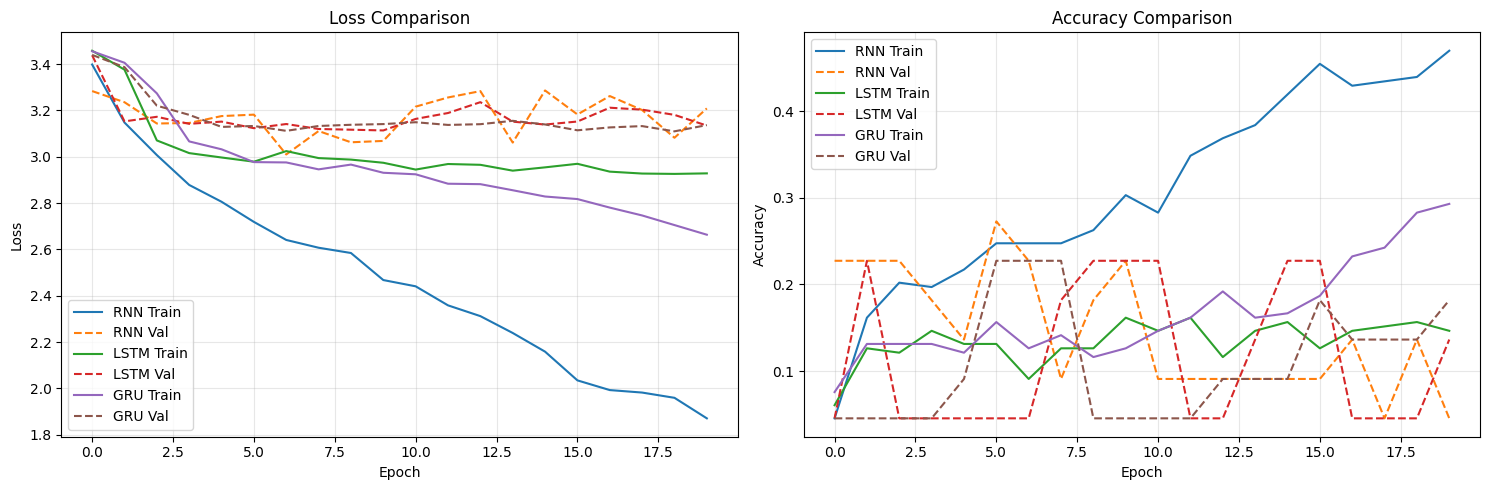

In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss comparison
axes[0].plot(history_rnn.history['loss'], label='RNN Train')
axes[0].plot(history_rnn.history['val_loss'], label='RNN Val', linestyle='--')
axes[0].plot(history_lstm.history['loss'], label='LSTM Train')
axes[0].plot(history_lstm.history['val_loss'], label='LSTM Val', linestyle='--')
axes[0].plot(history_gru.history['loss'], label='GRU Train')
axes[0].plot(history_gru.history['val_loss'], label='GRU Val', linestyle='--')
axes[0].set_title('Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(history_rnn.history['accuracy'], label='RNN Train')
axes[1].plot(history_rnn.history['val_accuracy'], label='RNN Val', linestyle='--')
axes[1].plot(history_lstm.history['accuracy'], label='LSTM Train')
axes[1].plot(history_lstm.history['val_accuracy'], label='LSTM Val', linestyle='--')
axes[1].plot(history_gru.history['accuracy'], label='GRU Train')
axes[1].plot(history_gru.history['val_accuracy'], label='GRU Val', linestyle='--')
axes[1].set_title('Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Text Generation

Let's generate text using the trained LSTM model.

In [14]:
def generate_text(model, seed_text, length=100, temperature=1.0):
    """
    Generate text using the trained model.
    temperature: controls randomness (lower = more conservative)
    """
    generated = seed_text
    
    for _ in range(length):
        # Prepare input
        sequence = [char_to_idx[ch] for ch in generated[-seq_length:]]
        sequence = np.array([sequence])
        
        # Predict next character
        predictions = model.predict(sequence, verbose=0)[0]
        predictions = np.asarray(predictions).astype('float64')
        predictions = np.log(predictions + 1e-10) / temperature
        exp_preds = np.exp(predictions)
        predictions = exp_preds / np.sum(exp_preds)
        
        # Sample next character
        next_idx = np.random.choice(len(predictions), p=predictions)
        next_char = idx_to_char[next_idx]
        
        generated += next_char
    
    return generated

In [16]:
# Generate text with different models and temperatures
seed = "Deep learning is a subset of machine "

print("=" * 60)
print("RNN Generated Text (temperature=0.1):")
print("=" * 60)
print(generate_text(model_rnn, seed, length=150, temperature=0.1))

print("\n" + "=" * 60)
print("LSTM Generated Text (temperature=0.1):")
print("=" * 60)
print(generate_text(model_lstm, seed, length=150, temperature=0.1))

print("\n" + "=" * 60)
print("GRU Generated Text (temperature=0.1):")
print("=" * 60)
print(generate_text(model_gru, seed, length=150, temperature=0.1))

print("\n" + "=" * 60)
print("LSTM Generated Text (temperature=1.0 - more random):")
print("=" * 60)
print(generate_text(model_lstm, seed, length=150, temperature=1.0))

RNN Generated Text (temperature=0.1):
Deep learning is a subset of machine lear rng  ena arne learnln nenr len uarn  ura  eana eeurnar  urrtraruaeg uraeuorear aenrnrn etra urearar rrar lea   ler raa erarrarnrnrearara uraarare

LSTM Generated Text (temperature=0.1):
Deep learning is a subset of machine e  ee e e ee e eee e e  ete ee   ee ee e ee  e er e e  e e er e e ee  e err e ee en e ee er e e e er  e ea e er eer  e ee  ee ee r ne e e  eee ee ere 

GRU Generated Text (temperature=0.1):
Deep learning is a subset of machine er e ne e er ere ne er e e e e ee nee er ere ne ne ne e ere ne neere re re e er eere ere re ee ne ne ne er er ne er ne ee ner e ee e rer erere ne ne n

LSTM Generated Text (temperature=1.0 - more random):
Deep learning is a subset of machine egnce oglgut e nnl nidn.rMrleeufkrrcd Mgwoi
io ei 
 wmRrpaolsitsarMkTacugtsMmL a ldi e a. lkrcewna a.nadumukdoRr rrotrcuNes thufRNgeccomk etnt  atletg


## Part 6: Bidirectional LSTM

Bidirectional LSTMs can learn from both past and future context.

In [17]:
# Build Bidirectional LSTM
model_bilstm = keras.Sequential([
    layers.Embedding(vocab_size, 32, input_length=seq_length),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.2),
    layers.Dense(vocab_size, activation='softmax')
])

model_bilstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_bilstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train Bidirectional LSTM
history_bilstm = model_bilstm.fit(
    X, y,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.0531 - loss: 3.4614 - val_accuracy: 0.0455 - val_loss: 3.4438
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1289 - loss: 3.4337 - val_accuracy: 0.0455 - val_loss: 3.4065
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1256 - loss: 3.3770 - val_accuracy: 0.0455 - val_loss: 3.2456
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1045 - loss: 3.1747 - val_accuracy: 0.0455 - val_loss: 3.2492
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1684 - loss: 3.0911 - val_accuracy: 0.0455 - val_loss: 3.1723
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1116 - loss: 3.0824 - val_accuracy: 0.2273 - val_loss: 3.1471
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1211 - loss: 3.0115 - val_accuracy: 0.2273 - val_loss: 3.1125
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1346 - loss: 2.9867 - val_accuracy: 0.2273 - val_loss: 3.1256


In [19]:
# Compare parameter counts
models = {
    'Simple RNN': model_rnn,
    'LSTM': model_lstm,
    'GRU': model_gru,
    'Bidirectional LSTM': model_bilstm
}

print("Model Comparison:")
print("=" * 50)
for name, model in models.items():
    params = model.count_params()
    print(f"{name:20s}: {params:,} parameters")

Model Comparison:
Simple RNN          : 25,760 parameters
LSTM                : 87,584 parameters
GRU                 : 67,360 parameters
Bidirectional LSTM  : 54,816 parameters


## Key Takeaways

### Simple RNN
- Simplest recurrent architecture
- Suffers from vanishing gradient problem
- Limited ability to learn long-term dependencies

### LSTM (Long Short-Term Memory)
- Uses gates (forget, input, output) to control information flow
- Can learn long-term dependencies
- More parameters than simple RNN
- Standard choice for many sequence tasks

### GRU (Gated Recurrent Unit)
- Simpler than LSTM (fewer gates)
- Fewer parameters, faster training
- Performance often comparable to LSTM
- Good balance between simplicity and effectiveness

### Bidirectional LSTM
- Processes sequence in both directions
- Better for tasks where future context matters
- Approximately 2x parameters of unidirectional version
- Not suitable for real-time prediction (needs full sequence)